In [1]:
#setwd("/home/mjehangir/data_analysis/mayo_clinin_project_data_analysis/manuscript_figures/")

In [1]:
data_dir = '/home/mjehangir/data_analysis/glioma_project_data_analysis/manuscript_figures/'

In [2]:
setwd(data_dir)

In [4]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)


In [5]:
# Load the Excel file
glioma_data <- read.xlsx("../glioma_project/gliomas_CNV_analysis/gliomas_update.xlsx", sheet = 1)

In [6]:
head(glioma_data)

,ADL.ID,Age.(date.of.collection.-.DOB),Mayo.Pathology.Grade,CDKN2A/B,TP53,ATRX,onco.Alterations,ONT.Alterations,X9
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,2436A,?,3,?,?,?,5,40,NA
2,3188,?,3,?,?,?,16,107,NA
3,3988,?l,2,2,0,0,17,105,NA
4,6265D,33,3,1,0,0,42,87,NA
5,6266D,40,2,1,0,0,28,105,NA
6,6269C,23,3,2,0,0,14,214,NA


In [7]:

glioma_data <- glioma_data %>%
  select(-X9, -`Age.(date.of.collection.-.DOB)`)


In [8]:
head(glioma_data)

,ADL.ID,Mayo.Pathology.Grade,CDKN2A/B,TP53,ATRX,onco.Alterations,ONT.Alterations
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,2436A,3,?,?,?,5,40
2,3188,3,?,?,?,16,107
3,3988,2,2,0,0,17,105
4,6265D,3,1,0,0,42,87
5,6266D,2,1,0,0,28,105
6,6269C,3,2,0,0,14,214


In [9]:
# Replace "?" with NA in all columns except for ADL.ID
glioma_data[glioma_data == "?"] <- NA

# Convert all columns except ADL.ID to numeric
glioma_matrix <- glioma_data[, -1]  # Remove ADL.ID
glioma_matrix[] <- lapply(glioma_matrix, as.numeric)  # Convert columns to numeric
rownames(glioma_matrix) <- glioma_data$ADL.ID  # Set row names to patient IDs


In [10]:
head(glioma_matrix)

,Mayo.Pathology.Grade,CDKN2A/B,TP53,ATRX,onco.Alterations,ONT.Alterations
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,3,NA,NA,NA,5,40
3188,3,NA,NA,NA,16,107
3988,2,2,0,0,17,105
6265D,3,1,0,0,42,87
6266D,2,1,0,0,28,105
6269C,3,2,0,0,14,214


In [11]:
# Convert to a data frame
glioma_matrix <- as.data.frame(glioma_matrix)



In [12]:
# Define a distinct color palette for each column
#color_palettes <- list(
#  Mayo.Pathology.Grade = colorRamp2(c(1, 2, 3), c("white", "indianred3", "indianred4")),
#  CDKN2A.B = colorRamp2(c(0, 1, 2), c("white", "tan3", "tan4")),
#  TP53 = colorRamp2(c(0, 1, 2), c("white", "skyblue", "skyblue3")),
#  ATRX = colorRamp2(c(0, 1, 2), c("white", "plum1", "plum4")),
#  onco.Alterations = colorRamp2(range(glioma_matrix[, "onco.Alterations"], na.rm = TRUE), c("white", "lightblue4")),
#  ONT.Alterations = colorRamp2(range(glioma_matrix[, "ONT.Alterations"], na.rm = TRUE), c("white", "palegreen4"))
#)


In [13]:
# Define a distinct color palette for each column
color_palettes <- list(
  Mayo.Pathology.Grade = colorRamp2(c(1, 2, 3), c("white", "indianred3", "indianred4")),
  CDKN2A.B = colorRamp2(c(0, 1, 2), c("tan4", "tan3", "white")),
  TP53 = colorRamp2(c(0, 1, 2), c("skyblue3", "skyblue", "white")),
  ATRX = colorRamp2(c(0, 1, 2), c("plum4", "plum1", "white")),
  onco.Alterations = colorRamp2(range(glioma_matrix[, "onco.Alterations"], na.rm = TRUE), c("white", "lightblue4")),
  ONT.Alterations = colorRamp2(range(glioma_matrix[, "ONT.Alterations"], na.rm = TRUE), c("white", "palegreen4"))
)

In [14]:
# Extract color functions from the color_palettes list
col_Mayo <- color_palettes$Mayo.Pathology.Grade
col_CDKN2A_B <- color_palettes$CDKN2A.B
col_TP53 <- color_palettes$TP53
col_ATRX <- color_palettes$ATRX
col_onco <- color_palettes$onco.Alterations
col_ONT <- color_palettes$ONT.Alterations

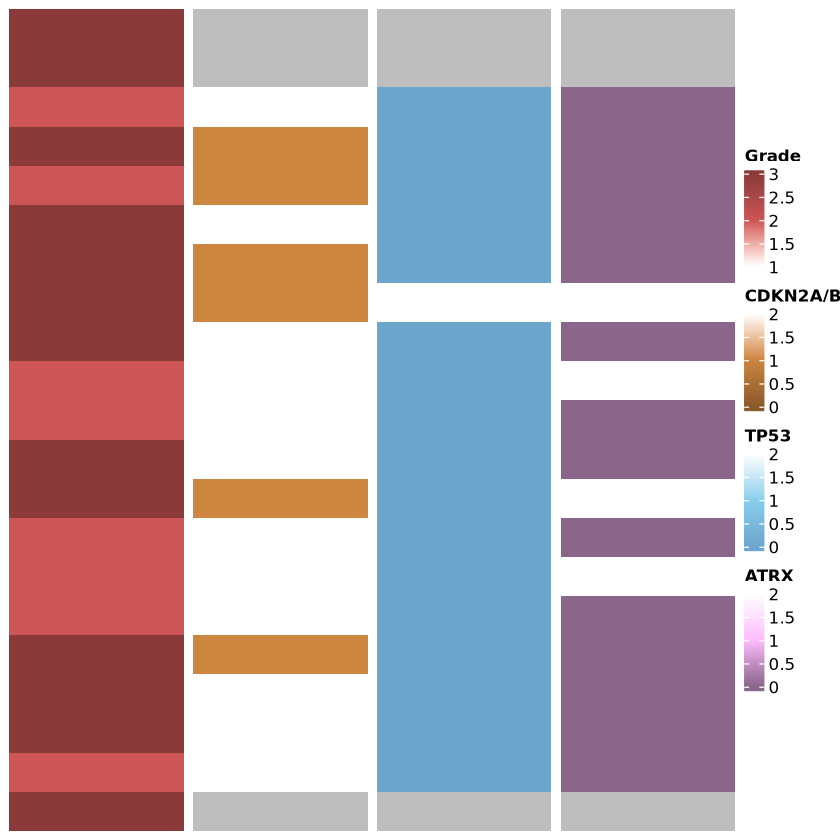

In [15]:
# Create individual heatmaps for each column
heatmap_Mayo <- Heatmap(
  glioma_matrix[["Mayo.Pathology.Grade"]],
  name = "Grade",
  col = col_Mayo,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
    show_row_names = TRUE,
  row_names_gp = gpar(fontsize = 10)
)

heatmap_CDKN2A_B <- Heatmap(
  glioma_matrix[["CDKN2A/B"]],
  name = "CDKN2A/B",
  col = col_CDKN2A_B,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10)
)

heatmap_TP53 <- Heatmap(
  glioma_matrix[["TP53"]],
  name = "TP53",
  col = col_TP53,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10)
)

heatmap_ATRX <- Heatmap(
  glioma_matrix[["ATRX"]],
  name = "ATRX",
  col = col_ATRX,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10)
)

heatmap_onco <- Heatmap(
  glioma_matrix[["onco.Alterations"]],
  name = "Onco.Alterations",
  col = col_onco,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10)
)

heatmap_ONT <- Heatmap(
  glioma_matrix[["ONT.Alterations"]],
  name = "ONT.Alterations",
  col = col_ONT,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10)
)

# Combine all heatmaps into a single plot
combined_heatmap <- heatmap_Mayo + heatmap_CDKN2A_B + heatmap_TP53 + heatmap_ATRX #+ heatmap_onco #+ heatmap_ONT

# Draw the combined heatmap
draw(combined_heatmap)

In [16]:

# Create individual heatmaps for each column
heatmap_Mayo <- Heatmap(
  glioma_matrix[["Mayo.Pathology.Grade"]],
  name = "Grade",
  col = col_Mayo,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10), # Adjust row name font size
  row_names_side = "left" # Show row names on the left
)

heatmap_CDKN2A_B <- Heatmap(
  glioma_matrix[["CDKN2A/B"]],
  name = "CDKN2A/B",
  col = col_CDKN2A_B,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10),
  row_names_side = "left"
)

heatmap_TP53 <- Heatmap(
  glioma_matrix[["TP53"]],
  name = "TP53",
  col = col_TP53,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10),
  row_names_side = "left"
)

heatmap_ATRX <- Heatmap(
  glioma_matrix[["ATRX"]],
  name = "ATRX",
  col = col_ATRX,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10),
  row_names_side = "left"
)

heatmap_onco <- Heatmap(
  glioma_matrix[["onco.Alterations"]],
  name = "Onco.Alterations",
  col = col_onco,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10),
  row_names_side = "left"
)

heatmap_ONT <- Heatmap(
  glioma_matrix[["ONT.Alterations"]],
  name = "ONT.Alterations",
  col = col_ONT,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 10),
  row_names_side = "left"
)

# Combine all heatmaps into a single plot
combined_heatmap <- heatmap_Mayo + heatmap_CDKN2A_B + heatmap_TP53 + heatmap_ATRX #+ heatmap_onco #+ heatmap_ONT




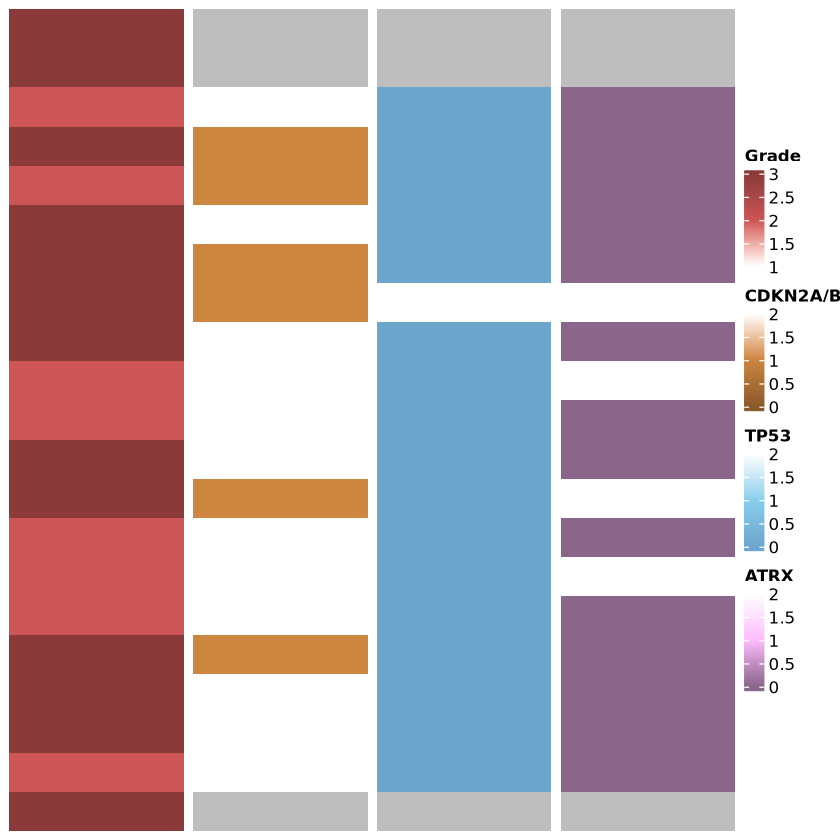

In [17]:


# Draw the combined heatmap
draw(combined_heatmap)

In [18]:
head(glioma_matrix)

,Mayo.Pathology.Grade,CDKN2A/B,TP53,ATRX,onco.Alterations,ONT.Alterations
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,3,NA,NA,NA,5,40
3188,3,NA,NA,NA,16,107
3988,2,2,0,0,17,105
6265D,3,1,0,0,42,87
6266D,2,1,0,0,28,105
6269C,3,2,0,0,14,214


In [19]:
print(glioma_data$ADL.ID)

 [1] "2436A"   "3188"    "3988"    "6265D"   "6266D"   "6269C"   "6277A"  
 [8] "6285B"   "6298B"   "6314E"   "6324B"   "6365A"   "6414C"   "6423A"  
[15] "6436B"   "6439C_2" "6439C_3" "6478A"   "6483C"   "6500D"   "6605D"  


In [20]:
# Assign sample IDs as rownames
rownames(glioma_matrix) <- c("2436A", "3188", "3988", "6265D", "6266D", "6269C", "6277A", 
                             "6285B", "6298B", "6314E", "6324B", "6365A", "6414C", "6423A", 
                             "6436B", "6439C_2", "6439C_3", "6478A", "6483C", "6500D", "6605D")


In [21]:
head(glioma_matrix)

,Mayo.Pathology.Grade,CDKN2A/B,TP53,ATRX,onco.Alterations,ONT.Alterations
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,3,NA,NA,NA,5,40
3188,3,NA,NA,NA,16,107
3988,2,2,0,0,17,105
6265D,3,1,0,0,42,87
6266D,2,1,0,0,28,105
6269C,3,2,0,0,14,214


In [22]:
#glioma_matrix <- as.matrix(glioma_matrix)

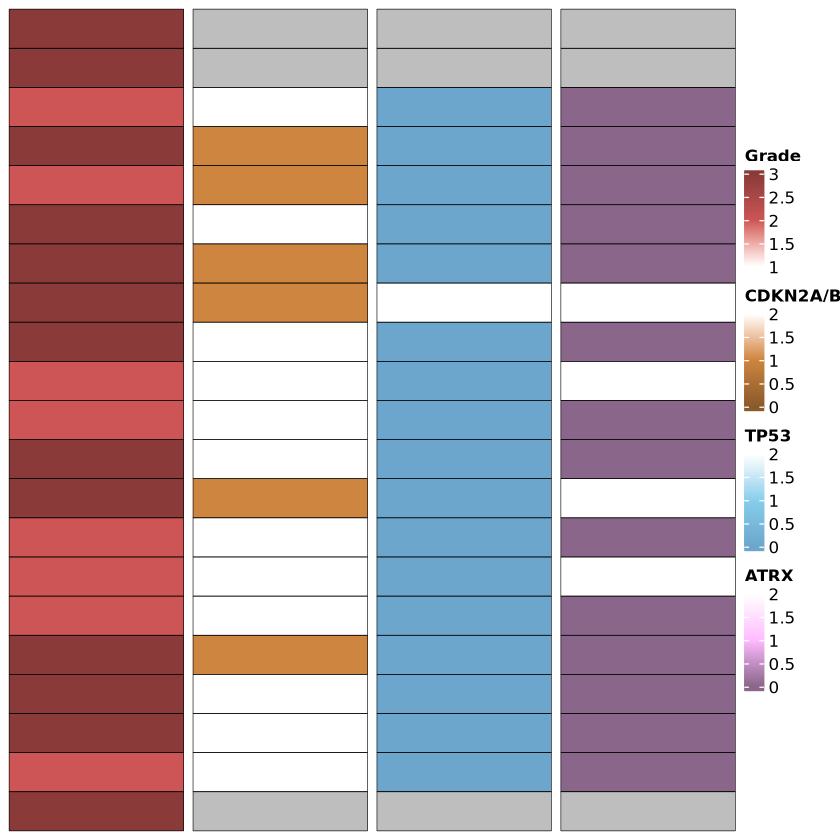

In [23]:
# Create individual heatmaps for each column with row names displayed
heatmap_Mayo <- Heatmap(
  glioma_matrix[["Mayo.Pathology.Grade"]],
  name = "Grade",
  col = color_palettes$Mayo.Pathology.Grade,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  row_names_side = "left",
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Add border
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
    # Add value labels
  }
)

heatmap_CDKN2A_B <- Heatmap(
  glioma_matrix[["CDKN2A/B"]],
  name = "CDKN2A/B",
  col = color_palettes$CDKN2A.B,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_TP53 <- Heatmap(
  glioma_matrix[["TP53"]],
  name = "TP53",
  col = color_palettes$TP53,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_ATRX <- Heatmap(
  glioma_matrix[["ATRX"]],
  name = "ATRX",
  col = color_palettes$ATRX,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
 show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_onco <- Heatmap(
  glioma_matrix[["onco.Alterations"]],
  name = "Onco.Alterations",
  col = color_palettes$onco.Alterations,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_ONT <- Heatmap(
  glioma_matrix[["ONT.Alterations"]],
  name = "ONT.Alterations",
  col = color_palettes$ONT.Alterations,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

# Combine all heatmaps into a single plot
combined_heatmap <- heatmap_Mayo + heatmap_CDKN2A_B + heatmap_TP53 + heatmap_ATRX #+ heatmap_onco + heatmap_ONT

# Draw the combined heatmap
draw(combined_heatmap)




In [24]:
head(glioma_matrix)

,Mayo.Pathology.Grade,CDKN2A/B,TP53,ATRX,onco.Alterations,ONT.Alterations
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,3,NA,NA,NA,5,40
3188,3,NA,NA,NA,16,107
3988,2,2,0,0,17,105
6265D,3,1,0,0,42,87
6266D,2,1,0,0,28,105
6269C,3,2,0,0,14,214


In [25]:
combined_heatmap <- heatmap_Mayo + heatmap_CDKN2A_B + heatmap_TP53 + heatmap_ATRX #+ heatmap_onco #+ heatmap_ONT


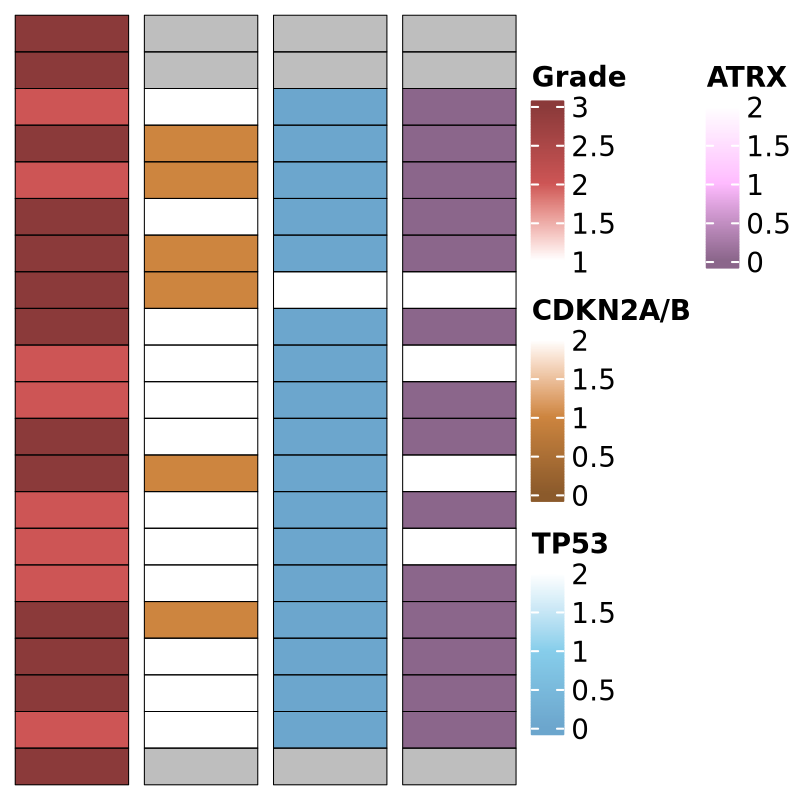

In [26]:
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 200)


draw(combined_heatmap)


In [27]:
head(glioma_matrix, n=20)

,Mayo.Pathology.Grade,CDKN2A/B,TP53,ATRX,onco.Alterations,ONT.Alterations
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,3,NA,NA,NA,5,40
3188,3,NA,NA,NA,16,107
3988,2,2,0,0,17,105
6265D,3,1,0,0,42,87
6266D,2,1,0,0,28,105
6269C,3,2,0,0,14,214
6277A,3,1,0,0,70,138
6285B,3,1,2,2,7,66
6298B,3,2,0,0,6,40


In [28]:
glioma_matrix <- glioma_matrix[rownames(glioma_matrix) != "6439C_2", ]

In [29]:
head(glioma_matrix, n=20)

,Mayo.Pathology.Grade,CDKN2A/B,TP53,ATRX,onco.Alterations,ONT.Alterations
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,3,NA,NA,NA,5,40
3188,3,NA,NA,NA,16,107
3988,2,2,0,0,17,105
6265D,3,1,0,0,42,87
6266D,2,1,0,0,28,105
6269C,3,2,0,0,14,214
6277A,3,1,0,0,70,138
6285B,3,1,2,2,7,66
6298B,3,2,0,0,6,40


In [51]:
# Define a distinct color palette for each column
color_palettes <- list(
  Mayo.Pathology.Grade = colorRamp2(c(1, 2, 3), c("white", "indianred3", "indianred4")),
  CDKN2A.B = colorRamp2(c(0, 1, 2), c("tan4", "tan3", "white")),
  TP53 = colorRamp2(c(0, 1, 2), c("skyblue3", "skyblue", "white")),
  ATRX = colorRamp2(c(0, 1, 2), c("plum4", "plum1", "white")),
  onco.Alterations = colorRamp2(range(glioma_matrix[, "onco.Alterations"], na.rm = TRUE), c("white", "lightblue4")),
  ONT.Alterations = colorRamp2(range(glioma_matrix[, "ONT.Alterations"], na.rm = TRUE), c("white", "palegreen4"))
)

In [52]:
# Extract color functions from the color_palettes list
col_Mayo <- color_palettes$Mayo.Pathology.Grade
col_CDKN2A_B <- color_palettes$CDKN2A.B
col_TP53 <- color_palettes$TP53
col_ATRX <- color_palettes$ATRX
col_onco <- color_palettes$onco.Alterations
col_ONT <- color_palettes$ONT.Alterations

In [53]:
heatmap_Mayo <- Heatmap(
  matrix = as.matrix(glioma_matrix[, "Mayo.Pathology.Grade", drop = FALSE]),
  name = "Grade",
  col = color_palettes$Mayo.Pathology.Grade,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  row_names_side = "left",
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Add border
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
    # Add value labels

  }
)

heatmap_CDKN2A_B <- Heatmap(
  matrix = as.matrix(glioma_matrix[, "CDKN2A/B", drop = FALSE]),
  name = "CDKN2A/B",
  col = color_palettes$CDKN2A.B,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_TP53 <- Heatmap(
  matrix = as.matrix(glioma_matrix[, "TP53", drop = FALSE]),
  name = "TP53",
  col = color_palettes$TP53,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)



heatmap_ATRX <- Heatmap(
  matrix = as.matrix(glioma_matrix[, "ATRX", drop = FALSE]),
  name = "ATRX",
  col = color_palettes$ATRX,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)


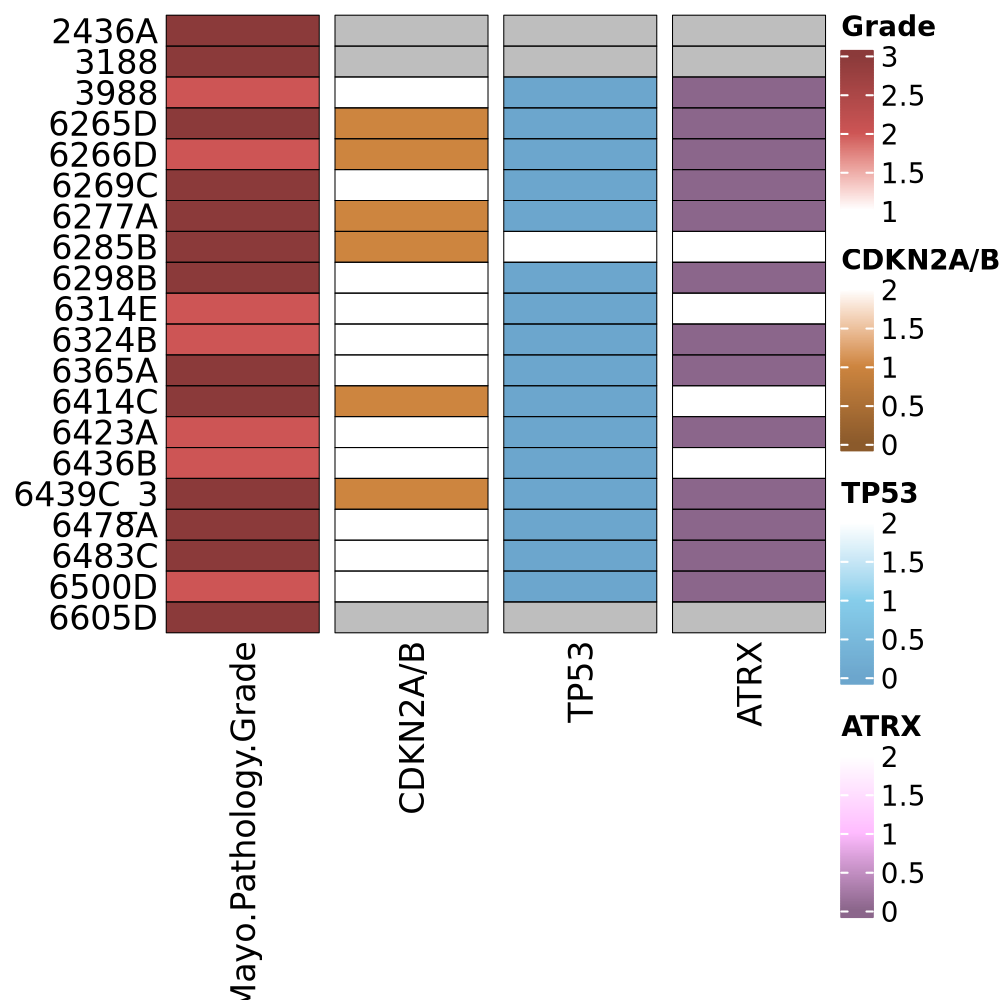

In [54]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

heatmap_Mayo + heatmap_CDKN2A_B + heatmap_TP53 + heatmap_ATRX


In [55]:
data_dir1 = '/scratch/mjehangir/Glioma_project/'

In [56]:
setwd(data_dir1)

In [57]:
#load the data files

summary_file = read.csv(file = "Gliomas_v2_output_taylor_aneuploidy_summary.txt", header = TRUE, sep = "\t")
anueploidy_prop = read.csv(file = "Gliomas_v2_output_prop_aneuploidy.txt", header = TRUE, sep = "\t")
taylor_file = read.csv(file = "Gliomas_v2_output_taylor_aneuploidy.txt", header = TRUE, sep = "\t")

In [58]:
#extract selected columns to plot heatmaps
summary_file2 = summary_file %>% select("SampleID", "prop_aneuploidy", "aneuploidy_score", "aneuploidy_amp_score", "aneuploidy_del_score")

In [59]:
# Extract each column separately for ploting
heatmap_matrix <- summary_file2[, -1] # Remove SampleID column
row.names(heatmap_matrix) <- summary_file2$SampleID

In [60]:
# Define color mappings for heatmaps
color_prop <- colorRamp2(c(0, 1), c("white", "darkgreen"))
color_score <- colorRamp2(c(0, max(heatmap_matrix$aneuploidy_score, na.rm = TRUE)), c("white", "orangered"))
color_amp <- colorRamp2(c(0, max(heatmap_matrix$aneuploidy_amp_score, na.rm = TRUE)), c("white", "darkred"))
color_del <- colorRamp2(c(0, max(heatmap_matrix$aneuploidy_del_score, na.rm = TRUE)), c("white", "darkblue"))


In [61]:
# this function will add border to heatmap tiles
cell_fun = function(j, i, x, y, width, height, fill) {
  grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.7, fill = NA))
}

In [62]:
# Create separate heatmaps files for each column data in ploidy summary file
heatmap_prop <- Heatmap(
  matrix = as.matrix(heatmap_matrix[, "prop_aneuploidy", drop = FALSE]),
  name = "Prop. Aneuploidy",
  col = color_prop,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Add border
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
    # Add value labels
    grid.text(
      sprintf("%.2f", heatmap_matrix[i, j]), # Format value to 2 decimal places
      x = x, y = y,
      gp = gpar(col = "white", fontsize = 8) # label text inside the boxes with font size 8
    )
  }
)


heatmap_score <- Heatmap(
  matrix = as.matrix(heatmap_matrix[, "aneuploidy_score", drop = FALSE]),
  name = "Aneuploidy Score",
  col = color_score,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_amp <- Heatmap(
  matrix = as.matrix(heatmap_matrix[, "aneuploidy_amp_score", drop = FALSE]),
  name = "Amp. Score",
  col = color_amp,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_del <- Heatmap(
  matrix = as.matrix(heatmap_matrix[, "aneuploidy_del_score", drop = FALSE]),
  name = "Del. Score",
  col = color_del,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)


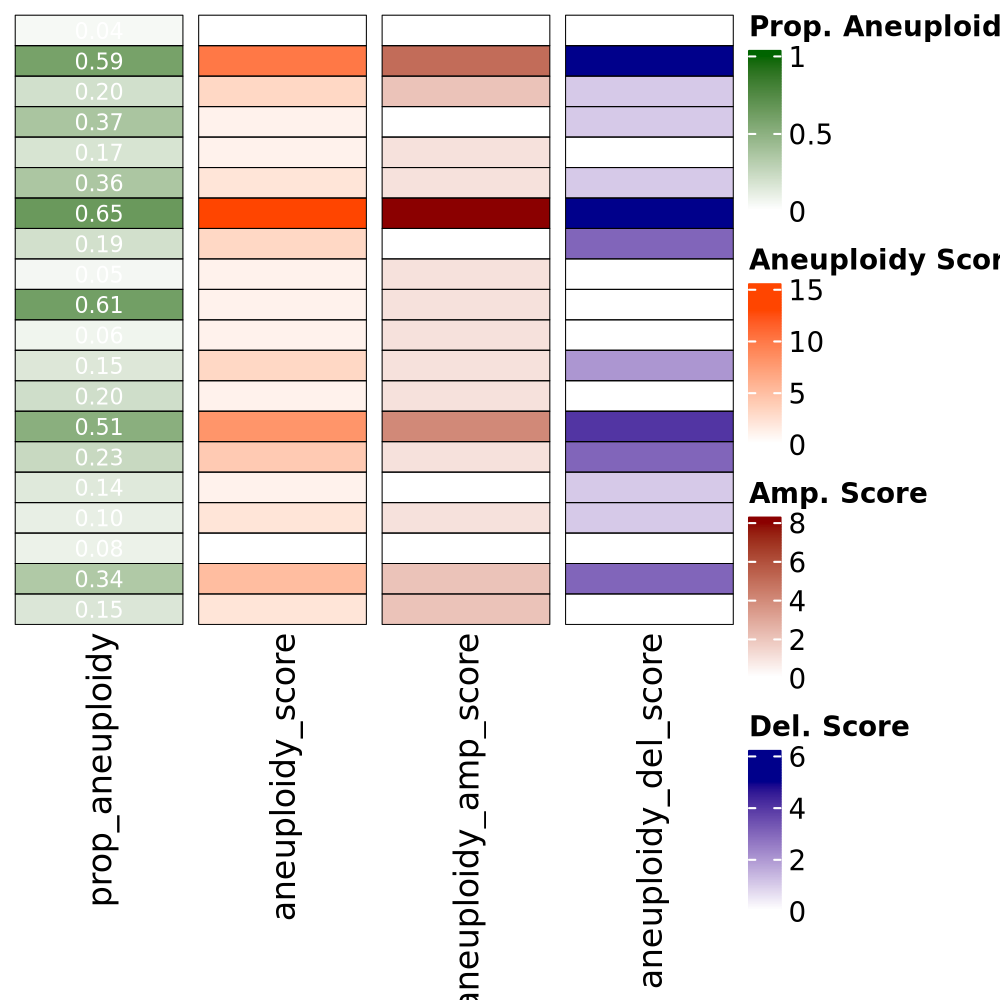

In [63]:
heatmap_prop + heatmap_score + heatmap_amp + heatmap_del

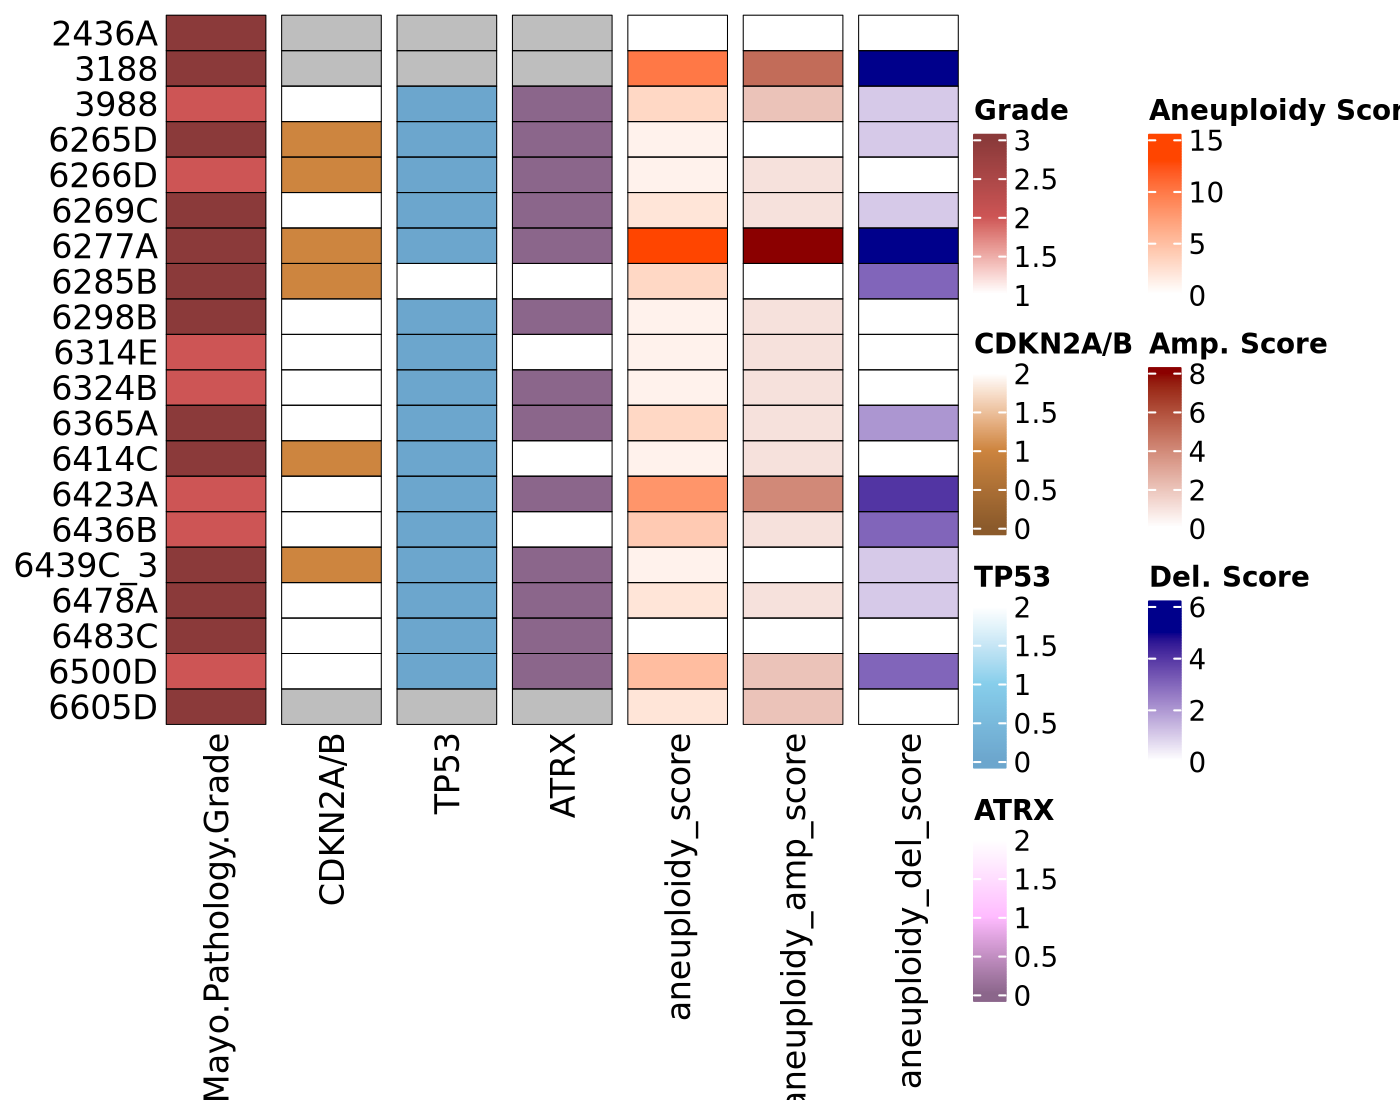

In [64]:

options(repr.plot.width = 7, repr.plot.height = 5.5, repr.plot.res = 200)

heatmap_Mayo + heatmap_CDKN2A_B + heatmap_TP53 + heatmap_ATRX + heatmap_score + heatmap_amp + heatmap_del

In [65]:
options(repr.plot.width = 7.5, repr.plot.height = 5.5, repr.plot.res = 200)

pdf(file = "heatmap_clinical_data_combined.pdf", width = 8, height = 6.5)
heatmap_Mayo + heatmap_CDKN2A_B + heatmap_TP53 + heatmap_ATRX + heatmap_score + heatmap_amp + heatmap_del
dev.off()

pdf 
  2